# Aula 04 - Inferencia estatistica aplicada a LLMs

Notebook pratico baseado em `ara01.pdf`.

Objetivos:
- ajustar regressao linear simples e multipla;
- interpretar estimativas pontuais, intervalos e residuos;
- aplicar o Teorema de Bayes ao exemplo de deteccao de alucinacao;
- transformar logits em probabilidades com softmax e temperatura;
- estimar probabilidades condicionais com um modelo bigrama;
- usar TCL e bootstrap para quantificar incerteza em metricas medias.

In [1]:
# Bibliotecas usadas ao longo do notebook.
# math: funcoes matematicas basicas, como raiz quadrada.
# Counter: contador util para frequencias de palavras no exemplo de bigramas.
import math
from collections import Counter

# Bibliotecas para analise, simulacao e visualizacao de dados.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st

# statsmodels sera usado para ajustar modelos lineares e obter inferencia estatistica.
import statsmodels.api as sm

# scikit-learn sera usado apenas na separacao treino/teste e na metrica de erro.
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Gerador de numeros aleatorios com semente fixa.
# Isso torna os resultados reproduziveis: ao reexecutar, os mesmos dados simulados aparecem.
rng = np.random.default_rng(42)

# Estilo visual dos graficos.
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Regressao linear simples

A aula apresenta o modelo `Y = beta0 + beta1 X + erro`. Vamos simular renda mensal como funcao dos anos de experiencia.

In [2]:
# Numero de observacoes da amostra. Cada linha representa uma pessoa.
n = 30

# Variavel explicativa X: anos de experiencia profissional.
# Usamos uma distribuicao uniforme para espalhar os valores entre 0 e 20 anos.
experiencia = rng.uniform(0, 20, size=n)

# Termo aleatorio epsilon: representa fatores nao observados que tambem afetam a renda,
# como area de atuacao, empresa, cargo, negociacao salarial etc.
# A media zero indica que esses fatores nao aumentam nem reduzem a renda sistematicamente.
erro = rng.normal(0, 900, size=n)

# Variavel resposta Y: renda mensal simulada.
# Modelo usado na simulacao: renda = beta0 + beta1 * experiencia + erro.
# beta0 = 2800: renda media esperada quando experiencia = 0.
# beta1 = 420: aumento medio esperado na renda para cada ano adicional de experiencia.
renda = 2800 + 420 * experiencia + erro

# Organizamos os vetores em uma tabela para facilitar analise, graficos e ajuste do modelo.
dados_renda = pd.DataFrame({"experiencia": experiencia, "renda": renda})

# Visualiza as primeiras linhas da amostra simulada.
dados_renda.head()

,experiencia,renda
0,15.479121,11228.713649
1,8.777569,6120.805379
2,17.171958,9551.204071
3,13.947361,7925.495989
4,1.883547,4145.471203


In [3]:
# Em regressao linear com statsmodels, precisamos incluir explicitamente a coluna constante.
# Essa constante representa o intercepto beta0 do modelo.
X = sm.add_constant(dados_renda["experiencia"])

# Ajuste por Minimos Quadrados Ordinarios (OLS):
# Y = renda, X = constante + experiencia.
modelo_simples = sm.OLS(dados_renda["renda"], X).fit()

# A tabela mostra estimativa, erro padrao, estatistica t, p-valor e intervalo de confianca.
modelo_simples.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,2976.5318,291.116,10.225,0.000,2380.207,3572.856
experiencia,413.3692,23.094,17.900,0.000,366.064,460.674


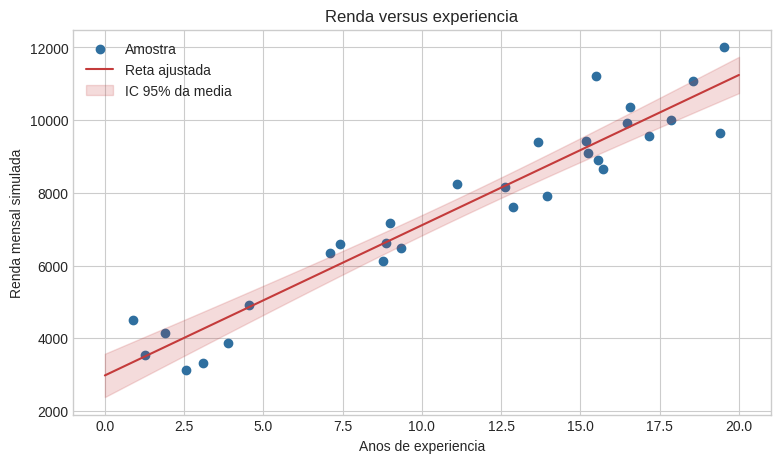

In [4]:
# Criamos uma grade de valores de experiencia para desenhar a reta ajustada de forma suave.
grade = pd.DataFrame({"experiencia": np.linspace(0, 20, 100)})

# Para cada valor da grade, calculamos a renda media estimada e seu intervalo de confianca.
pred = modelo_simples.get_prediction(sm.add_constant(grade)).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(9, 5))

# Pontos observados na amostra simulada.
ax.scatter(dados_renda["experiencia"], dados_renda["renda"], label="Amostra", color="#2f6f9f")

# Reta estimada pelo modelo: a melhor reta segundo o criterio de minimos quadrados.
ax.plot(grade["experiencia"], pred["mean"], label="Reta ajustada", color="#c43b3b")

# Faixa de incerteza para a media estimada da renda em cada nivel de experiencia.
ax.fill_between(
    grade["experiencia"],
    pred["mean_ci_lower"].to_numpy(),
    pred["mean_ci_upper"].to_numpy(),
    color="#c43b3b",
    alpha=0.18,
    label="IC 95% da media",
)

ax.set(title="Renda versus experiencia", xlabel="Anos de experiencia", ylabel="Renda mensal simulada")
ax.legend()
plt.show()

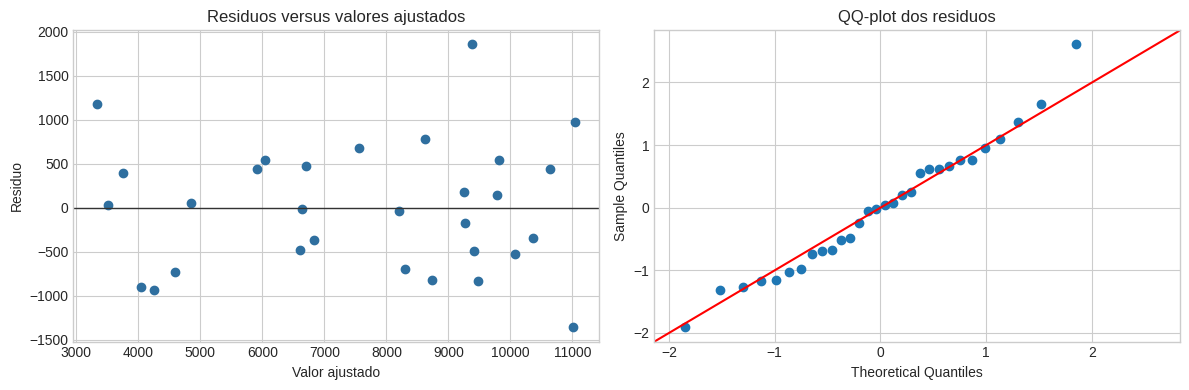

In [5]:
# Residuos sao as diferencas entre o valor observado e o valor previsto pelo modelo.
# Eles ajudam a avaliar se o modelo linear esta capturando bem o padrao dos dados.
residuos = modelo_simples.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Idealmente, os residuos devem ficar espalhados ao redor de zero sem padrao evidente.
axes[0].scatter(modelo_simples.fittedvalues, residuos, color="#2f6f9f")
axes[0].axhline(0, color="#333333", linewidth=1)
axes[0].set(title="Residuos versus valores ajustados", xlabel="Valor ajustado", ylabel="Residuo")

# O QQ-plot compara os residuos com uma distribuicao normal.
# Pontos proximos da reta indicam que a suposicao de normalidade e razoavel.
sm.qqplot(residuos, line="45", fit=True, ax=axes[1])
axes[1].set(title="QQ-plot dos residuos")

plt.tight_layout()
plt.show()

## 2. Regressao linear multipla

Agora simulamos preco de imoveis com mais de uma variavel explicativa, como no exemplo da aula.

In [6]:
# Numero de imoveis simulados.
n = 160

# Variaveis explicativas do preco.
# metragem e continua; quartos e uma contagem; localizacao e categorica.
metragem = rng.normal(85, 22, size=n).clip(35, 180)
quartos = rng.choice([1, 2, 3, 4], size=n, p=[0.12, 0.38, 0.36, 0.14])
localizacao = rng.choice(["centro", "bairro", "periferia"], size=n, p=[0.30, 0.50, 0.20])

# Efeito medio adicional de cada localizacao no preco.
# A periferia fica como referencia com efeito 0.
efeito_local = {"centro": 90000, "bairro": 35000, "periferia": 0}

# Simulamos o preco a partir de uma relacao linear multipla.
# Cada coeficiente representa o efeito medio de uma variavel mantendo as outras constantes.
preco = (
    90000
    + 4300 * metragem
    + 28000 * quartos
    + np.array([efeito_local[x] for x in localizacao])
    + rng.normal(0, 45000, size=n)
)

# Tabela final com a variavel resposta e as variaveis explicativas.
imoveis = pd.DataFrame({"preco": preco, "metragem": metragem, "quartos": quartos, "localizacao": localizacao})
imoveis.head()

,preco,metragem,quartos,localizacao
0,339386.412570,47.976865,1,bairro
1,573296.927096,77.632529,3,periferia
2,650813.301715,88.580567,3,centro
3,550576.929596,97.896891,1,periferia
4,684194.345424,100.646985,2,bairro


In [7]:
# Modelos lineares precisam de variaveis numericas.
# get_dummies transforma a variavel categorica localizacao em colunas indicadoras.
# drop_first=True evita redundancia: uma categoria vira a referencia do modelo.
imoveis_modelo = pd.get_dummies(imoveis, columns=["localizacao"], drop_first=True, dtype=float)

# y e a variavel resposta; X contem as variaveis explicativas.
y = imoveis_modelo["preco"]
X = sm.add_constant(imoveis_modelo.drop(columns="preco"))

# Ajuste da regressao linear multipla por OLS.
modelo_multiplo = sm.OLS(y, X).fit()

# Tabela de inferencia dos coeficientes.
modelo_multiplo.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,1.058e+05,1.8e+04,5.869,0.000,7.02e+04,1.41e+05
metragem,4423.3373,183.311,24.130,0.000,4061.227,4785.447
quartos,2.789e+04,4224.628,6.601,0.000,1.95e+04,3.62e+04
localizacao_centro,6.094e+04,8408.766,7.247,0.000,4.43e+04,7.76e+04
localizacao_periferia,-2.061e+04,9583.128,-2.150,0.033,-3.95e+04,-1677.464


In [8]:
# Intervalos de confianca de 95% para cada coeficiente.
# Eles mostram uma faixa plausivel para o parametro populacional.
coeficientes = modelo_multiplo.conf_int(alpha=0.05)
coeficientes.columns = ["ic_025", "ic_975"]

# Juntamos estimativa pontual e p-valor na mesma tabela para facilitar a interpretacao.
coeficientes["estimativa"] = modelo_multiplo.params
coeficientes["p_valor"] = modelo_multiplo.pvalues
coeficientes

,ic_025,ic_975,estimativa,p_valor
const,70176.949178,141376.743018,105776.846098,2.567122e-08
metragem,4061.227390,4785.447272,4423.337331,2.324264e-54
quartos,19542.265141,36232.817770,27887.541456,6.130865e-10
localizacao_centro,44331.738807,77552.876451,60942.307629,1.880253e-11
localizacao_periferia,-39538.241029,-1677.463717,-20607.852373,3.307154e-02


## 3. Teorema de Bayes: detector de alucinacao

Exemplo da aula: prevalencia de alucinacao `P(H=1)=0.12`, sensibilidade `P(A=+|H=1)=0.91` e especificidade `P(A=-|H=0)=0.96`.

In [9]:
# H=1 significa que a resposta contem alucinacao.
# A=- significa que o detector classificou a resposta como segura.
p_h = 0.12
sensibilidade = 0.91      # P(A=+ | H=1): chance de detectar alucinacao quando ela existe.
especificidade = 0.96     # P(A=- | H=0): chance de dizer seguro quando nao ha alucinacao.

# Complementos necessarios para aplicar Bayes.
p_a_neg_dado_h = 1 - sensibilidade      # falso negativo: detector diz seguro apesar de haver alucinacao.
p_a_neg_dado_sem_h = especificidade     # verdadeiro negativo.
p_sem_h = 1 - p_h                       # P(H=0).

# Teorema de Bayes: atualiza a probabilidade de alucinacao apos observar A=-.
p_h_dado_a_neg = (p_a_neg_dado_h * p_h) / (p_a_neg_dado_h * p_h + p_a_neg_dado_sem_h * p_sem_h)
print(f"P(H=1 | A=-) = {p_h_dado_a_neg:.4%}")

P(H=1 | A=-) = 1.2623%


Mesmo quando o detector classifica a resposta como segura, a probabilidade residual de alucinacao nao e zero.

## 4. Softmax e temperatura

LLMs produzem logits. A softmax converte esses scores em uma distribuicao de probabilidade. A temperatura controla a concentracao dessa distribuicao.

In [10]:
# Tokens candidatos para completar uma frase como "A capital do Parana e ...".
tokens = np.array(["Curitiba", "Londrina", "Maringa", "Ponta Grossa", "Cascavel"])

# Logits sao scores brutos do modelo: ainda nao sao probabilidades.
# Quanto maior o logit, maior tende a ser a probabilidade depois da softmax.
logits = np.array([8.2, 5.1, 4.4, 3.2, 2.8])


def softmax_com_temperatura(z, temperatura=1.0):
    # Dividir pela temperatura altera a concentracao da distribuicao.
    # T < 1 deixa a distribuicao mais concentrada; T > 1 deixa mais espalhada.
    z_ajustado = z / temperatura

    # Subtrair o maximo melhora a estabilidade numerica sem mudar as probabilidades finais.
    z_ajustado = z_ajustado - np.max(z_ajustado)

    # Exponenciamos os logits e normalizamos para que a soma seja 1.
    exp_z = np.exp(z_ajustado)
    return exp_z / exp_z.sum()


# Comparamos uma temperatura baixa, uma neutra e uma alta.
temperaturas = [0.2, 1.0, 1.5]
probs = pd.DataFrame({f"T={t}": softmax_com_temperatura(logits, t) for t in temperaturas}, index=tokens)
probs

,T=0.2,T=1.0,T=1.5
Curitiba,9.999998e-01,0.927064,0.788023
Londrina,1.855391e-07,0.041763,0.099769
Maringa,5.602795e-09,0.020739,0.062564
Ponta Grossa,1.388794e-11,0.006247,0.028112
Cascavel,1.879528e-12,0.004187,0.021532


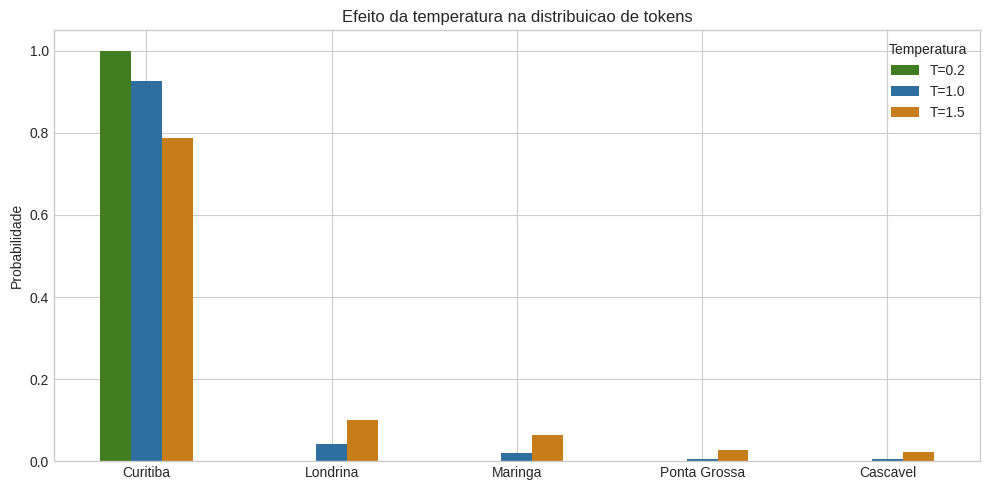

In [11]:
# Grafico de barras para visualizar como a temperatura redistribui as probabilidades.
# Em temperatura baixa, o token mais provavel domina; em temperatura alta, outros tokens ganham chance.
ax = probs.plot(kind="bar", figsize=(10, 5), rot=0, color=["#3f7d20", "#2f6f9f", "#c77d1a"])
ax.set(title="Efeito da temperatura na distribuicao de tokens", ylabel="Probabilidade")
ax.legend(title="Temperatura")
plt.tight_layout()
plt.show()

## 5. Modelo de linguagem bigrama

Um bigrama estima `P(w_t | w_{t-1})` por contagem: `count(w_{t-1}, w_t) / count(w_{t-1})`.

In [12]:
# Corpus pequeno para estimar probabilidades condicionais por contagem.
# Em um LLM real, essa ideia aparece em escala muito maior e com representacoes vetoriais.
corpus = [
    "ia e interessante",
    "ia e poderosa",
    "ia e moderna",
    "modelo de linguagem aprende probabilidades",
    "modelo de linguagem prediz tokens",
    "temperatura controla probabilidades de tokens",
]

# contagem_contexto guarda quantas vezes uma palavra aparece como contexto anterior.
# contagem_bigrama guarda quantas vezes cada par (palavra anterior, palavra atual) aparece.
contagem_contexto = Counter()
contagem_bigrama = Counter()

for frase in corpus:
    palavras = frase.split()

    # zip(palavras[:-1], palavras[1:]) percorre pares consecutivos da frase.
    for anterior, atual in zip(palavras[:-1], palavras[1:]):
        contagem_contexto[anterior] += 1
        contagem_bigrama[(anterior, atual)] += 1

# Calculamos P(proximo_token | contexto) = contagem(contexto, proximo_token) / contagem(contexto).
linhas = []
for (anterior, atual), contagem in sorted(contagem_bigrama.items()):
    linhas.append({
        "contexto": anterior,
        "proximo_token": atual,
        "contagem": contagem,
        "probabilidade": contagem / contagem_contexto[anterior],
    })

bigrama = pd.DataFrame(linhas)
bigrama

,contexto,proximo_token,contagem,probabilidade
0,aprende,probabilidades,1,1.000000
1,controla,probabilidades,1,1.000000
2,de,linguagem,2,0.666667
3,de,tokens,1,0.333333
4,e,interessante,1,0.333333
5,e,moderna,1,0.333333
6,e,poderosa,1,0.333333
7,ia,e,3,1.000000
8,linguagem,aprende,1,0.500000
9,linguagem,prediz,1,0.500000


In [13]:
def proximos_tokens(contexto):
    # Filtra os candidatos que ja apareceram depois do contexto informado.
    candidatos = bigrama[bigrama["contexto"] == contexto].sort_values("probabilidade", ascending=False)

    # Se o contexto nao apareceu no corpus, nao ha estimativa por contagem simples.
    if candidatos.empty:
        return pd.DataFrame({"mensagem": [f"Contexto '{contexto}' nao observado no corpus."]})

    # Retorna os proximos tokens possiveis e suas probabilidades condicionais estimadas.
    return candidatos[["proximo_token", "probabilidade"]]


proximos_tokens("ia")

,proximo_token,probabilidade
7,e,1.0


## 6. Teorema Central do Limite e bootstrap

Em avaliacoes de LLMs, muitas metricas sao medias sobre prompts. O TCL permite aproximar a incerteza da media; o bootstrap reamostra os dados para estimar a variabilidade.

In [14]:
# Simulamos perdas de 120 prompts avaliados em um modelo.
# A distribuicao gamma e assimetrica, o que torna o exemplo mais realista que uma normal perfeita.
perdas = rng.gamma(shape=2.2, scale=0.45, size=120)

# Media observada da perda: estimativa pontual do desempenho medio.
media = perdas.mean()

# Erro padrao da media: mede a incerteza da estimativa da media.
erro_padrao = perdas.std(ddof=1) / math.sqrt(len(perdas))

# Intervalo de confianca usando aproximacao pelo TCL e distribuicao t.
ic_normal = st.t.interval(confidence=0.95, df=len(perdas) - 1, loc=media, scale=erro_padrao)

# Bootstrap: reamostramos as perdas com reposicao e recalculamos a media muitas vezes.
bootstrap_medias = np.array([rng.choice(perdas, size=len(perdas), replace=True).mean() for _ in range(5000)])

# Percentis 2.5% e 97.5% das medias bootstrap formam um IC aproximado de 95%.
ic_bootstrap = np.quantile(bootstrap_medias, [0.025, 0.975])

pd.DataFrame({
    "metodo": ["TCL / t", "Bootstrap"],
    "media": [media, bootstrap_medias.mean()],
    "ic_025": [ic_normal[0], ic_bootstrap[0]],
    "ic_975": [ic_normal[1], ic_bootstrap[1]],
})

,metodo,media,ic_025,ic_975
0,TCL / t,0.948000,0.841261,1.054739
1,Bootstrap,0.947866,0.845934,1.050782


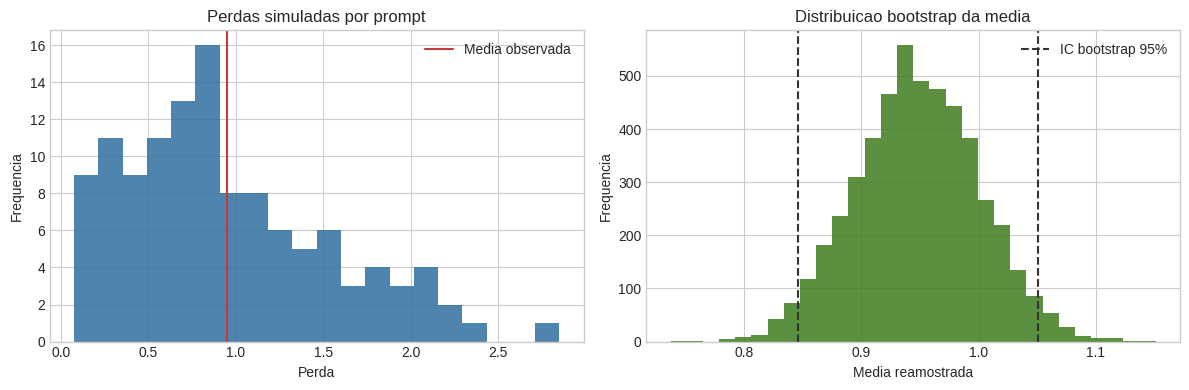

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuicao das perdas individuais dos prompts.
axes[0].hist(perdas, bins=20, color="#2f6f9f", alpha=0.85)
axes[0].axvline(media, color="#c43b3b", label="Media observada")
axes[0].set(title="Perdas simuladas por prompt", xlabel="Perda", ylabel="Frequencia")
axes[0].legend()

# Distribuicao das medias obtidas por bootstrap.
# Ela mostra como a media poderia variar se observassemos outra amostra semelhante.
axes[1].hist(bootstrap_medias, bins=30, color="#3f7d20", alpha=0.85)
axes[1].axvline(ic_bootstrap[0], color="#333333", linestyle="--", label="IC bootstrap 95%")
axes[1].axvline(ic_bootstrap[1], color="#333333", linestyle="--")
axes[1].set(title="Distribuicao bootstrap da media", xlabel="Media reamostrada", ylabel="Frequencia")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Generalizacao: treino e teste

A inferencia estatistica ajuda a estimar relacoes; a avaliacao fora da amostra verifica se o modelo generaliza para dados novos.

In [16]:
# Separacao treino/teste: o modelo aprende no treino e e avaliado em dados nao usados no ajuste.
treino, teste = train_test_split(imoveis_modelo, test_size=0.25, random_state=42)

# Montamos X e y para treino e teste mantendo a mesma estrutura de colunas.
X_treino = sm.add_constant(treino.drop(columns="preco"))
y_treino = treino["preco"]
X_teste = sm.add_constant(teste.drop(columns="preco"))
y_teste = teste["preco"]

# Ajustamos o modelo somente com dados de treino.
modelo_treino = sm.OLS(y_treino, X_treino).fit()

# Geramos previsoes para treino e teste.
pred_treino = modelo_treino.predict(X_treino)
pred_teste = modelo_treino.predict(X_teste)

# RMSE mede o erro medio de previsao na mesma unidade da resposta, aqui em reais.
# Comparar treino e teste ajuda a observar generalizacao.
pd.DataFrame({
    "conjunto": ["treino", "teste"],
    "rmse": [
        np.sqrt(mean_squared_error(y_treino, pred_treino)),
        np.sqrt(mean_squared_error(y_teste, pred_teste)),
    ],
})

,conjunto,rmse
0,treino,41521.349169
1,teste,55990.480603
